In [127]:
graphics_toolkit('gnuplot')

In [128]:
format free

In [129]:
a = 0; b = 1; h = 0.1; alpha = 1; delta = 0.01;
n = round((b - a) / h);
N = n + 1;              
s = (a:h:b)';

In [130]:
C = zeros(N,N);
for i = 2:N-1
    C(i,i-1) = -alpha/h^2;
    C(i,i)   = alpha * (1 + 2/h^2);
    C(i,i+1) = -alpha/h^2;
end
C(1,1) = 1; C(1,2) = -1;
C(N,N-1) = -1; C(N,N) = 1;

C

C =

 1 -1 0 0 0 0 0 0 0 0 0
 -100 201 -100 0 0 0 0 0 0 0 0
 0 -100 201 -100 0 0 0 0 0 0 0
 0 0 -100 201 -100 0 0 0 0 0 0
 0 0 0 -100 201 -100 0 0 0 0 0
 0 0 0 0 -100 201 -100 0 0 0 0
 0 0 0 0 0 -100 201 -100 0 0 0
 0 0 0 0 0 0 -100 201 -100 0 0
 0 0 0 0 0 0 0 -100 201 -100 0
 0 0 0 0 0 0 0 0 -100 201 -100
 0 0 0 0 0 0 0 0 0 -1 1



In [131]:
i = (0:n)';
z_exact = cos(pi * s);

b = C * z_exact

b =

 0.0489435
 10.2607
 8.72824
 6.34144
 3.33389
 2.09217e-14
 -3.33389
 -6.34144
 -8.72824
 -10.2607
 -0.0489435



In [132]:
delta = 0.01;
b_delta = b + delta * rand(size(b))

b_delta =

 0.0544884
 10.2677
 8.73351
 6.34469
 3.33719
 0.00272349
 -3.32446
 -6.33893
 -8.71854
 -10.2595
 -0.0441536



In [133]:
cond(C)
det(C)
rcond(C)

ans = 20777.4
ans = 1.0247e+17
ans = 2.00721e-05


In [134]:
z_new = C \ b_delta

z_new =

 1.13201
 1.07752
 0.93113
 0.706716
 0.425923
 0.116016
 -0.192757
 -0.470214
 -0.688983
 -0.827457
 -0.87161



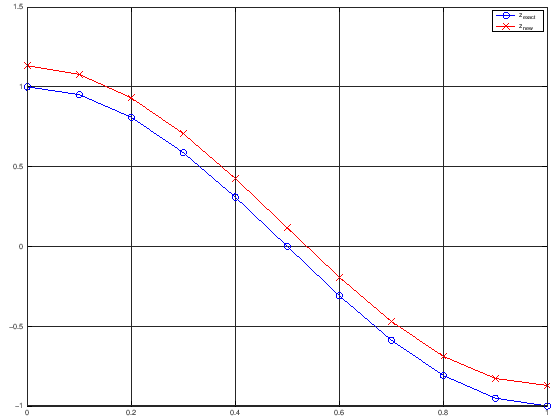

In [135]:
plot(s, z_exact, 'b-o', s, z_new, 'r-x')
grid on
legend('z_{exact}', 'z_{new}')

In [136]:
sigma = 0.1;

A = zeros(N, N);
for i = 1:N
    for j = 1:N
        x_i = s(i);
        s_j = s(j);
        K = (x_i) * (1 - x_i) * (1 - s_j) * s_j;    
        A(i, j) = K * h;         
    end
end

In [137]:
A

A =

 0 0 0 0 0 0 0 0 0 0 0
 0 0.00081 0.00144 0.00189 0.00216 0.00225 0.00216 0.00189 0.00144 0.00081 0
 0 0.00144 0.00256 0.00336 0.00384 0.004 0.00384 0.00336 0.00256 0.00144 0
 0 0.00189 0.00336 0.00441 0.00504 0.00525 0.00504 0.00441 0.00336 0.00189 0
 0 0.00216 0.00384 0.00504 0.00576 0.006 0.00576 0.00504 0.00384 0.00216 0
 0 0.00225 0.004 0.00525 0.006 0.00625 0.006 0.00525 0.004 0.00225 0
 0 0.00216 0.00384 0.00504 0.00576 0.006 0.00576 0.00504 0.00384 0.00216 0
 0 0.00189 0.00336 0.00441 0.00504 0.00525 0.00504 0.00441 0.00336 0.00189 0
 0 0.00144 0.00256 0.00336 0.00384 0.004 0.00384 0.00336 0.00256 0.00144 0
 0 0.00081 0.00144 0.00189 0.00216 0.00225 0.00216 0.00189 0.00144 0.00081 0
 0 0 0 0 0 0 0 0 0 0 0



B = A^T * A

In [138]:
B = A' * A;
B

B =

 0 0 0 0 0 0 0 0 0 0 0
 0 2.69973e-05 4.79952e-05 6.29937e-05 7.19928e-05 7.49925e-05 7.19928e-05 6.29937e-05 4.79952e-05 2.69973e-05 0
 0 4.79952e-05 8.53248e-05 0.000111989 0.000127987 0.00013332 0.000127987 0.000111989 8.53248e-05 4.79952e-05 0
 0 6.29937e-05 0.000111989 0.000146985 0.000167983 0.000174983 0.000167983 0.000146985 0.000111989 6.29937e-05 0
 0 7.19928e-05 0.000127987 0.000167983 0.000191981 0.00019998 0.000191981 0.000167983 0.000127987 7.19928e-05 0
 0 7.49925e-05 0.00013332 0.000174983 0.00019998 0.000208313 0.00019998 0.000174983 0.00013332 7.49925e-05 0
 0 7.19928e-05 0.000127987 0.000167983 0.000191981 0.00019998 0.000191981 0.000167983 0.000127987 7.19928e-05 0
 0 6.29937e-05 0.000111989 0.000146985 0.000167983 0.000174983 0.000167983 0.000146985 0.000111989 6.29937e-05 0
 0 4.79952e-05 8.53248e-05 0.000111989 0.000127987 0.00013332 0.000127987 0.000111989 8.53248e-05 4.79952e-05 0
 0 2.69973e-05 4.79952e-05 6.29937e-05 7.19928e-05 7.49925e-05 7.19928e-05 6

In [139]:
S = B + C;
U = S * z_exact
z_new_full = S \ U;

U =

 0.0489435
 10.2607
 8.72824
 6.34144
 3.33389
 2.32311e-14
 -3.33389
 -6.34144
 -8.72824
 -10.2607
 -0.0489435



In [140]:
U_delta = U + delta * rand(size(U));
z_noise = S \ U_delta

z_noise =

 1.11931
 1.06829
 0.925318
 0.704253
 0.426801
 0.120247
 -0.185149
 -0.459109
 -0.674286
 -0.809001
 -0.849255



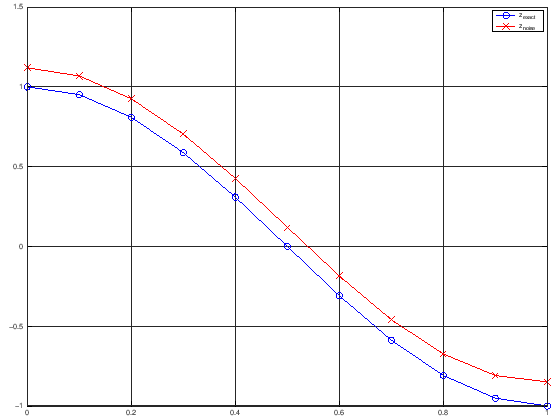

In [141]:
plot(s, z_exact, 'b-o', s, z_noise, 'r-x')
grid on
legend('z_{exact}', 'z_{noise}')